In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 

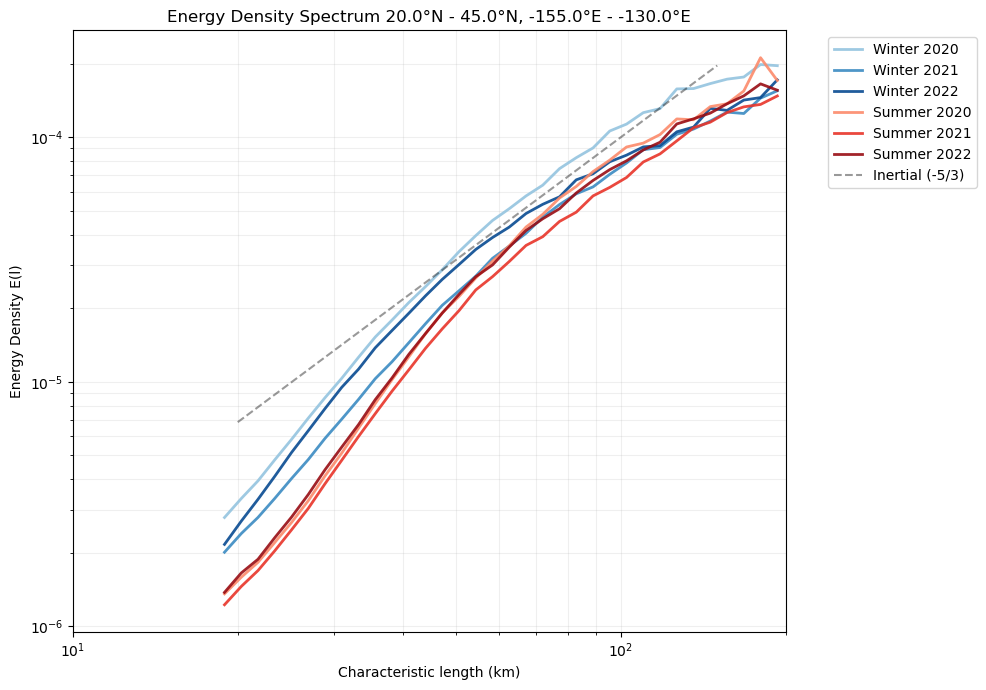

In [4]:
# 1. Define Subdomain (Flexible GPGP size)
lat_s, lat_n = 20.0, 45.0
lon_w, lon_e = -155.0, -130.0
les_box = [lon_w, lon_e, lat_s, lat_n]

# 2. Setup Dataset Groups and Color Families
data_groups = {
    "Winter": {
        "2020": "../data/GPGP_jan2020.nc",
        "2021": "../data/GPGP_jan2021.nc",
        "2022": "../data/GPGP_jan2022.nc"
    },
    "Summer": {
        "2020": "../data/GPGP_aug2020.nc",
        "2021": "../data/GPGP_aug2021.nc",
        "2022": "../data/GPGP_aug2022.nc"
    }
}

base_colors = {
    "Winter": "Blues",
    "Summer": "Reds",
    "Spring": "Greens", 
    "Autumn": "Oranges"
}


MAX_W = 200
plt.figure(figsize=(10, 7))

for species, years in data_groups.items():
    cmap = plt.get_cmap(base_colors[species])
    shades = np.linspace(0.4, 0.9, len(years))
    
    for idx, (year_label, path) in enumerate(years.items()):        
        # Call the third alternative function
        eds = oa.calculate_EDS_alternative(path, les_box, max_wavelength_km=MAX_W)
        
        l_km = eds.characteristic_length / 1000.0
        
        # Plot with specific species color shading
        plt.loglog(l_km, eds, 
                   label=f"{species} {year_label}", 
                   color=cmap(shades[idx]), 
                   lw=2, alpha=0.9)

# Reference Slope
x_ref = np.array([20, 150])
plt.loglog(x_ref, 1e-4*(x_ref/100)**(5/3), 'k--', alpha=0.4, label='Inertial (-5/3)')

plt.xlabel("Characteristic length (km)")
plt.ylabel("Energy Density E(l)")
plt.title(f"Energy Density Spectrum {lat_s}°N - {lat_n}°N, {lon_w}°E - {lon_e}°E")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", alpha=0.2)
plt.xlim(10, MAX_W) # Show the full 800km range
plt.tight_layout()
plt.show()